## Imports

In [1]:
import os
import math
import random
import shutil
from pathlib import Path

import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

## DATASET 

In [2]:
def split_dataset(img_dir, mask_dir, output_dir, split=(0.8, 0.1, 0.1), seed=42):
    random.seed(seed)
    img_dir    = Path(img_dir)
    mask_dir   = Path(mask_dir)
    output_dir = Path(output_dir)

    filenames = sorted([f.stem for f in img_dir.glob("*.jpg")])
    random.shuffle(filenames)

    n       = len(filenames)
    n_train = int(n * split[0])
    n_val   = int(n * split[1])

    splits = {
        "train": filenames[:n_train],
        "val"  : filenames[n_train:n_train + n_val],
        "test" : filenames[n_train + n_val:]
    }

    for split_name, files in splits.items():
        for subfolder in ["images", "masks"]:
            (output_dir / split_name / subfolder).mkdir(parents=True, exist_ok=True)
        for fname in files:
            shutil.copy(img_dir  / f"{fname}.jpg", output_dir / split_name / "images" / f"{fname}.jpg")
            shutil.copy(mask_dir / f"{fname}.jpg", output_dir / split_name / "masks"  / f"{fname}.jpg")
        print(f"{split_name}: {len(files)} samples")


In [3]:
img_dir    = "/kaggle/input/kvasirseg/Kvasir-SEG/Kvasir-SEG/images"
mask_dir   = "/kaggle/input/kvasirseg/Kvasir-SEG/Kvasir-SEG/masks"
output_dir = "/kaggle/working/"

In [4]:
split_dataset(img_dir=img_dir, mask_dir=mask_dir, output_dir=output_dir)

train: 800 samples
val: 100 samples
test: 100 samples


In [5]:
class MedSegDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.imgs      = sorted(os.listdir(img_dir))
        self.masks     = sorted(os.listdir(mask_dir))
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img  = np.array(Image.open(os.path.join(self.img_dir,  self.imgs[idx])).convert("RGB"))
        mask = np.array(Image.open(os.path.join(self.mask_dir, self.masks[idx])).convert("L"))
        if self.transform:
            out  = self.transform(image=img, mask=mask)
            img  = out["image"]
            mask = out["mask"]
        mask = (mask > 0.5).float().unsqueeze(0)
        return img, mask

## Transforms

In [6]:
train_tf = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_tf = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

In [7]:
train_ds = MedSegDataset("/kaggle/working/train/images", "/kaggle/working/train/masks", transform=train_tf)
val_ds   = MedSegDataset("/kaggle/working/val/images",   "/kaggle/working/val/masks",   transform=val_tf)
test_ds  = MedSegDataset("/kaggle/working/test/images",  "/kaggle/working/test/masks",  transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
# NOTE: batch_size reduced from 16 → 8 because the Transformer bottleneck
# uses more GPU memory than the NonLocalBlock did.

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 800 | Val: 100 | Test: 100


## CNN BUILDING BLOCKS

In [8]:
class DoubleConv(nn.Module):
    """
    Conv(3×3) → BN → ReLU → Conv(3×3) → BN → ReLU
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels,  out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class EncoderBlock(nn.Module):
    """
    MaxPool(2×2) → DoubleConv
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x):
        x = self.pool(x)
        x = self.conv(x)
        return x


class DecoderBlock(nn.Module):
    """
    Upsample(2×) → Concat(skip) → DoubleConv
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
        x = torch.cat([skip, x], dim=1)
        x = self.conv(x)
        return x


## TRANSFORMER BLOCKS

In [9]:
class PatchEmbed(nn.Module):
    """
    How it works:
      1. Flatten the spatial dims: (B, C, H, W) → (B, C, H*W)
      2. Transpose:                (B, C, N)    → (B, N, C)
      3. Project channels:         (B, N, C)    → (B, N, embed_dim)

    Args:
        in_channels : channels of the CNN feature map (1024 at bottleneck)
        embed_dim   : Transformer hidden dimension (default 512)
    """
    def __init__(self, in_channels, embed_dim):
        super().__init__()
        # Linear projection: maps each spatial position's features → embed_dim
        self.proj = nn.Linear(in_channels, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        """
        x    : (B, C, H, W)   — CNN feature map
        out  : (B, H*W, embed_dim)   — token sequence
        """
        B, C, H, W = x.shape
        # Flatten spatial dims and transpose
        x = x.flatten(2)          # (B, C, H*W)
        x = x.transpose(1, 2)     # (B, H*W, C)  = (B, N, C)
        x = self.proj(x)           # (B, N, embed_dim)
        x = self.norm(x)
        return x, H, W             # return H,W so we can reshape back later


class MultiHeadSelfAttention(nn.Module):
    """
    Multi-Head Self-Attention (the core of the Transformer).

    The math:
      Q = x @ W_Q    (what am I looking for?)
      K = x @ W_K    (what do I have to offer?)
      V = x @ W_V    (what information do I carry?)

      Attention(Q, K, V) = softmax( QKᵀ / √d_k ) · V

      Multi-head: run this h times in parallel, concat, project.

    Args:
        embed_dim : total hidden dimension
        num_heads : number of parallel attention heads
        dropout   : attention dropout (regularization)
    """
    def __init__(self, embed_dim, num_heads, dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0, \
            f"embed_dim ({embed_dim}) must be divisible by num_heads ({num_heads})"

        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads   # dimension per head
        self.scale     = self.head_dim ** -0.5    # 1/√d_k scaling factor

        # Single matrix for Q, K, V projection (efficient: one matmul instead of 3)
        self.qkv     = nn.Linear(embed_dim, embed_dim * 3, bias=False)
        self.proj    = nn.Linear(embed_dim, embed_dim)     # output projection
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        x   : (B, N, embed_dim)   — token sequence
        out : (B, N, embed_dim)   — same shape, attended features
        """
        B, N, C = x.shape

        # ── Project to Q, K, V ──────────────────────────────────────────────
        # (B, N, 3*C) → split into 3 × (B, N, C)
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)   # (3, B, heads, N, head_dim)
        q, k, v = qkv.unbind(0)             # each: (B, heads, N, head_dim)

        # ── Scaled Dot-Product Attention ────────────────────────────────────
        # QKᵀ: (B, heads, N, head_dim) × (B, heads, head_dim, N) → (B, heads, N, N)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)         # normalize: each row sums to 1
        attn = self.dropout(attn)

        # ── Weighted sum of Values ──────────────────────────────────────────
        # (B, heads, N, N) × (B, heads, N, head_dim) → (B, heads, N, head_dim)
        x = (attn @ v)
        x = x.transpose(1, 2).reshape(B, N, C)  # concat heads → (B, N, C)

        # ── Output Projection ───────────────────────────────────────────────
        x = self.proj(x)
        return x


class FeedForward(nn.Module):
    """
    Args:
        embed_dim : input/output dimension
        mlp_ratio : expansion factor (hidden = embed_dim * mlp_ratio)
        dropout   : regularization dropout
    """
    def __init__(self, embed_dim, mlp_ratio=4, dropout=0.0):
        super().__init__()
        hidden = int(embed_dim * mlp_ratio)
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    """
    Args:
        embed_dim : hidden dimension
        num_heads : parallel attention heads
        mlp_ratio : FFN expansion factor
        dropout   : dropout rate
    """
    def __init__(self, embed_dim, num_heads, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.attn  = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.ffn   = FeedForward(embed_dim, mlp_ratio, dropout)

    def forward(self, x):
        # Pre-LN attention with residual
        x = x + self.attn(self.norm1(x))
        # Pre-LN FFN with residual
        x = x + self.ffn(self.norm2(x))
        return x


class TransformerEncoder(nn.Module):
    """
    Args:
        depth     : number of Transformer blocks (TransUNet paper uses 12,
                    we use 6 here for efficiency on 256×256 input)
        embed_dim : hidden dimension (must match PatchEmbed output)
        num_heads : attention heads per block
        mlp_ratio : FFN expansion factor
        dropout   : dropout rate
    """
    def __init__(self, depth, embed_dim, num_heads, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)  # final norm after all blocks

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return self.norm(x)


## TRANSUNET FULL MODEL 

In [10]:
class TransUNet(nn.Module):
    """
    TransUNet: Transformer Bottleneck U-Net
    ========================================
    Family 1a — Hybrid Encoder + CNN Decoder

    The CNN encoder extracts hierarchical features exactly as in NonLocalUNet.
    At the bottleneck, instead of a NonLocalBlock, we:
      1. Flatten the feature map into a token sequence (PatchEmbed)
      2. Add learnable positional encoding (so Transformer knows spatial order)
      3. Process with a TransformerEncoder (multi-head self-attention × depth)
      4. Reshape tokens back to 2D spatial feature map
    Then the CNN decoder proceeds identically.

    Flow (256×256 input, base_filters=64):
    ─────────────────────────────────────────────────────────
    INPUT       (B,  3, 256, 256)
    enc1        (B,  64, 256, 256)   ← DoubleConv (no pool)
    enc2        (B, 128, 128, 128)   ← Pool + DoubleConv
    enc3        (B, 256,  64,  64)   ← Pool + DoubleConv
    enc4        (B, 512,  32,  32)   ← Pool + DoubleConv
    bottleneck  (B,1024,  16,  16)   ← Pool + DoubleConv

    [NEW TRANSFORMER BOTTLENECK]
    PatchEmbed  (B, 256, 512)        ← 16×16=256 tokens, each dim 512
    + pos_embed (B, 256, 512)        ← learnable position info added
    Transformer (B, 256, 512)        ← 6 × TransformerBlock
    Reshape     (B,1024,  16,  16)   ← project back + reshape to spatial
    [END TRANSFORMER BOTTLENECK]

    dec1        (B, 512,  32,  32)   ← Up + Concat(enc4) + DoubleConv
    dec2        (B, 256,  64,  64)   ← Up + Concat(enc3) + DoubleConv
    dec3        (B, 128, 128, 128)   ← Up + Concat(enc2) + DoubleConv
    dec4        (B,  64, 256, 256)   ← Up + Concat(enc1) + DoubleConv
    OUTPUT      (B,   1, 256, 256)   ← Conv1×1

    Args:
        in_channels      : input image channels (3 for RGB)
        num_classes      : output channels (1 for binary segmentation)
        base_filters     : base CNN channel count (default 64)
        embed_dim        : Transformer hidden dimension (default 512)
        transformer_depth: number of Transformer blocks (default 6)
        num_heads        : attention heads (default 8)
        mlp_ratio        : FFN expansion factor (default 4)
        dropout          : dropout rate (default 0.1)
    """

    def __init__(
        self,
        in_channels=3,
        num_classes=1,
        base_filters=64,
        embed_dim=512,
        transformer_depth=6,
        num_heads=8,
        mlp_ratio=4,
        dropout=0.1
    ):
        super(TransUNet, self).__init__()

        f = base_filters    # 64, 128, 256, 512, 1024

        # ── CNN Encoder ──────────────────────────────────────────────────────
     
        # Only change: use_nonlocal parameter removed
        self.enc1 = DoubleConv(in_channels, f)       # (B, 64,  H,    W)
        self.enc2 = EncoderBlock(f,    f*2)           # (B, 128, H/2,  W/2)
        self.enc3 = EncoderBlock(f*2,  f*4)           # (B, 256, H/4,  W/4)
        self.enc4 = EncoderBlock(f*4,  f*8)           # (B, 512, H/8,  W/8)

        # ── CNN Bottleneck ───────────────────────────────────────────────────
     
        self.bottleneck = EncoderBlock(f*8, f*16)     # (B, 1024, H/16, W/16)

        # ── Transformer Bottleneck ───────────────────────────────────────────
  
   
        self.patch_embed = PatchEmbed(in_channels=f*16, embed_dim=embed_dim)

        # Learnable positional encoding
        # Shape: (1, max_patches, embed_dim) — broadcast over batch
        # I use 16*16=256 for 256×256 images. Adjust if you change image size.
        self.pos_embed = nn.Parameter(torch.zeros(1, 256, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)  # standard ViT init

        # Dropout after positional embedding (regularization)
        self.pos_drop = nn.Dropout(dropout)

        # The Transformer encoder — replaces NonLocalBlock
        self.transformer = TransformerEncoder(
            depth     = transformer_depth,
            embed_dim = embed_dim,
            num_heads = num_heads,
            mlp_ratio = mlp_ratio,
            dropout   = dropout
        )

        # Project Transformer output (embed_dim) back to bottleneck channels (f*16)
        # Needed because Transformer embed_dim may differ from f*16
        self.trans_proj = nn.Sequential(
            nn.Linear(embed_dim, f*16),
            nn.LayerNorm(f*16)
        )

        # ── CNN Decoder ──────────────────────────────────────────────────────

        self.dec1 = DecoderBlock(f*16 + f*8,  f*8)   # (B, 512,  H/8,  W/8)
        self.dec2 = DecoderBlock(f*8  + f*4,  f*4)   # (B, 256,  H/4,  W/4)
        self.dec3 = DecoderBlock(f*4  + f*2,  f*2)   # (B, 128,  H/2,  W/2)
        self.dec4 = DecoderBlock(f*2  + f,    f)     # (B,  64,  H,    W)

        # ── Output Head ──────────────────────────────────────────────────────

        self.output_conv = nn.Conv2d(f, num_classes, kernel_size=1)

    def forward(self, x):
        # ── CNN Encoder ──────────────────────────────────────────────────────

        s1 = self.enc1(x)       # (B,  64, 256, 256)
        s2 = self.enc2(s1)      # (B, 128, 128, 128)
        s3 = self.enc3(s2)      # (B, 256,  64,  64)
        s4 = self.enc4(s3)      # (B, 512,  32,  32)

        # ── CNN Bottleneck ───────────────────────────────────────────────────
        bn = self.bottleneck(s4)  # (B, 1024, 16, 16)

        # ── Transformer Bottleneck ───────────────────────────────────────────

        tokens, H, W = self.patch_embed(bn)    # (B, 256, embed_dim)

        #   Step 2: Add positional encoding so Transformer knows spatial order
        #   Without this, the Transformer treats all tokens as unordered.
        tokens = tokens + self.pos_embed[:, :tokens.size(1), :]
        tokens = self.pos_drop(tokens)

        #   Step 3: Run through all Transformer blocks
        tokens = self.transformer(tokens)      # (B, 256, embed_dim)

        #   Step 4: Project back to bottleneck channel dimension
        tokens = self.trans_proj(tokens)       # (B, 256, f*16=1024)

        #   Step 5: Reshape tokens back to 2D spatial feature map
        B = tokens.size(0)
        bn = tokens.transpose(1, 2).reshape(B, -1, H, W)   # (B, 1024, 16, 16)
        # ── End Transformer Bottleneck ───────────────────────────────────────

        # ── CNN Decoder ──────────────────────────────────────────────────────
        d1 = self.dec1(bn, s4)  # (B, 512,  32,  32)
        d2 = self.dec2(d1, s3)  # (B, 256,  64,  64)
        d3 = self.dec3(d2, s2)  # (B, 128, 128, 128)
        d4 = self.dec4(d3, s1)  # (B,  64, 256, 256)

        # ── Output ───────────────────────────────────────────────────────────
        return self.output_conv(d4)  # (B, 1, 256, 256)

##  LOSS & METRICS 

In [11]:
class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.bce    = nn.BCEWithLogitsLoss()   # ← NOTE: changed from BCELoss
        self.smooth = smooth                    # BCEWithLogitsLoss is numerically
                                                # more stable (fused sigmoid+BCE)

    def dice_loss(self, pred, target):
        pred         = torch.sigmoid(pred)      # apply sigmoid since we use logits
        intersection = (pred * target).sum(dim=(2, 3))
        union        = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice         = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()

    def forward(self, pred, target):
        return self.bce(pred, target) + self.dice_loss(pred, target)


def dice_score(pred, target, threshold=0.5, smooth=1e-6):
    pred         = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum(dim=(2, 3))
    union        = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    return ((2 * intersection + smooth) / (union + smooth)).mean().item()


def iou_score(pred, target, threshold=0.5, smooth=1e-6):
    pred         = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum(dim=(2, 3))
    union        = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) - intersection
    return ((intersection + smooth) / (union + smooth)).mean().item()

## TRAINING LOOP 

In [12]:
def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()
    total_loss, total_dice, total_iou = 0, 0, 0

    for imgs, masks in tqdm(loader, desc="Train", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()

        if scaler is not None:
            # AMP (Automatic Mixed Precision) — optional, saves GPU memory
            with torch.cuda.amp.autocast():
                preds = model(imgs)
                loss  = criterion(preds, masks)
            scaler.scale(loss).backward()

            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            preds = model(imgs)
            loss  = criterion(preds, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        total_loss += loss.item()
        total_dice += dice_score(preds, masks)
        total_iou  += iou_score(preds, masks)

    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_dice, total_iou = 0, 0, 0

    for imgs, masks in tqdm(loader, desc="Val  ", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        loss  = criterion(preds, masks)
        total_loss += loss.item()
        total_dice += dice_score(preds, masks)
        total_iou  += iou_score(preds, masks)

    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n

## PLOT 

In [13]:
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"],   label="Val")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

    axes[1].plot(epochs, history["train_dice"], label="Train")
    axes[1].plot(epochs, history["val_dice"],   label="Val")
    axes[1].set_title("Dice Score"); axes[1].set_xlabel("Epoch"); axes[1].legend()

    axes[2].plot(epochs, history["train_iou"], label="Train")
    axes[2].plot(epochs, history["val_iou"],   label="Val")
    axes[2].set_title("IoU Score"); axes[2].set_xlabel("Epoch"); axes[2].legend()

    plt.tight_layout()
    plt.savefig("training_history_transunet.png", dpi=150)
    plt.show()

## TRAIN FUNCTION

In [14]:
def train(model, train_loader, val_loader, epochs=50, lr=1e-4, device="cuda"):
    criterion = BCEDiceLoss()

    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)


    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )

    # Optional: AMP scaler (set to None to disable, saves memory if enabled)
    scaler = torch.cuda.amp.GradScaler() if device == "cuda" else None

    history = {
        "train_loss": [], "val_loss": [],
        "train_dice": [], "val_dice": [],
        "train_iou" : [], "val_iou" : []
    }

    best_dice = 0.0

    for epoch in range(1, epochs + 1):
        train_loss, train_dice, train_iou = train_one_epoch(
            model, train_loader, optimizer, criterion, device, scaler
        )
        val_loss, val_dice, val_iou = evaluate(model, val_loader, criterion, device)

        scheduler.step()  # CosineAnnealingLR steps every epoch (not on val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_dice"].append(train_dice)
        history["val_dice"].append(val_dice)
        history["train_iou"].append(train_iou)
        history["val_iou"].append(val_iou)

        print(f"Epoch [{epoch:02d}/{epochs}]  "
              f"Loss: {train_loss:.4f}/{val_loss:.4f}  "
              f"Dice: {train_dice:.4f}/{val_dice:.4f}  "
              f"IoU: {train_iou:.4f}/{val_iou:.4f}")

        if val_dice > best_dice:
            best_dice = val_dice
            torch.save(model.state_dict(), "best_transunet.pth")
            print(f"  ✓ Best model saved (Dice: {best_dice:.4f})")

    plot_history(history)
    return history

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"


model = TransUNet(
    in_channels       = 3,
    num_classes       = 1,
    base_filters      = 64,
    embed_dim         = 512,       # Transformer hidden dim
    transformer_depth = 6,         # number of Transformer blocks
    num_heads         = 8,         # attention heads (512/8 = 64 per head)
    mlp_ratio         = 4,         # FFN hidden = 512*4 = 2048
    dropout           = 0.1
).to(device)

In [16]:
# Quick shape check before training
dummy = torch.randn(2, 3, 256, 256).to(device)
out   = model(dummy)
print(f"Output shape: {out.shape}")   # should be (2, 1, 256, 256)
assert out.shape == (2, 1, 256, 256), f"Shape mismatch: {out.shape}"
print("✓ Shape check passed")

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Output shape: torch.Size([2, 1, 256, 256])
✓ Shape check passed
Total parameters: 51,475,201


/tmp/ipykernel_55/4119995683.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device == "cuda" else None
Train:   0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_55/3252445767.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [01/50]  Loss: 1.2832/1.1560  Dice: 0.4387/0.5197  IoU: 0.3134/0.3868
  ✓ Best model saved (Dice: 0.5197)


Epoch [02/50]  Loss: 1.1253/1.0606  Dice: 0.4960/0.4619  IoU: 0.3661/0.3422


Epoch [03/50]  Loss: 1.0581/0.9286  Dice: 0.5229/0.6073  IoU: 0.3928/0.4676
  ✓ Best model saved (Dice: 0.6073)


Epoch [04/50]  Loss: 0.9932/0.8523  Dice: 0.5546/0.6463  IoU: 0.4238/0.5116
  ✓ Best model saved (Dice: 0.6463)


...

Epoch [46/50]  Loss: 0.2219/0.4504  Dice: 0.9017/0.8281  IoU: 0.8375/0.7526
  ✓ Best model saved (Dice: 0.8281)


Epoch [47/50]  Loss: 0.2250/0.4450  Dice: 0.9016/0.8293  IoU: 0.8382/0.7527
  ✓ Best model saved (Dice: 0.8293)


Epoch [48/50]  Loss: 0.2192/0.4454  Dice: 0.9038/0.8295  IoU: 0.8408/0.7538
  ✓ Best model saved (Dice: 0.8295)


Epoch [49/50]  Loss: 0.2202/0.4437  Dice: 0.9024/0.8295  IoU: 0.8395/0.7540


Epoch [50/50]  Loss: 0.2147/0.4510  Dice: 0.9047/0.8281  IoU: 0.8425/0.7528


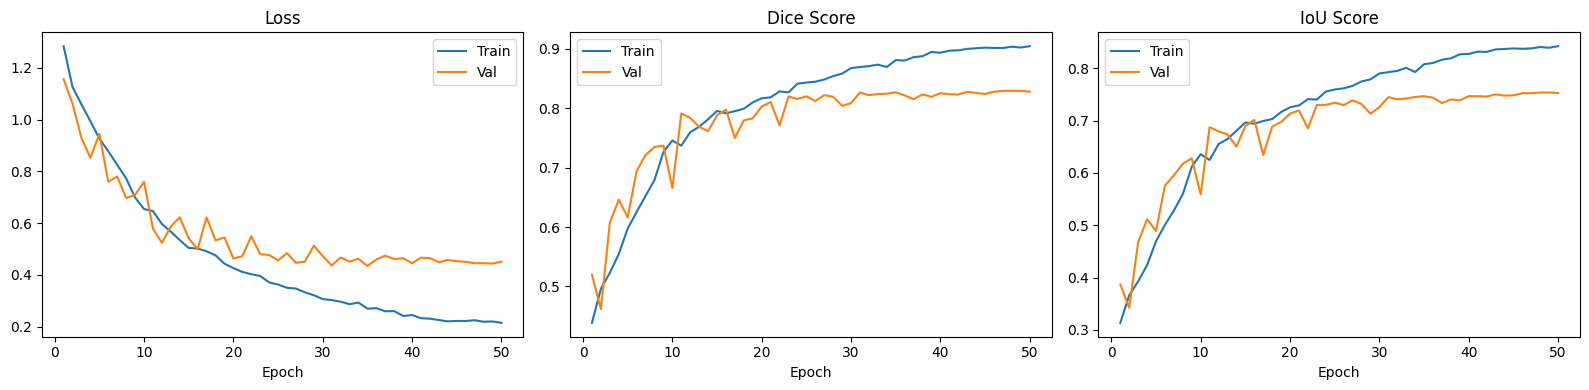

In [17]:
history = train(model, train_loader, val_loader, epochs=50, lr=1e-4, device=device)

## INFERENCE & VISUALIZATION

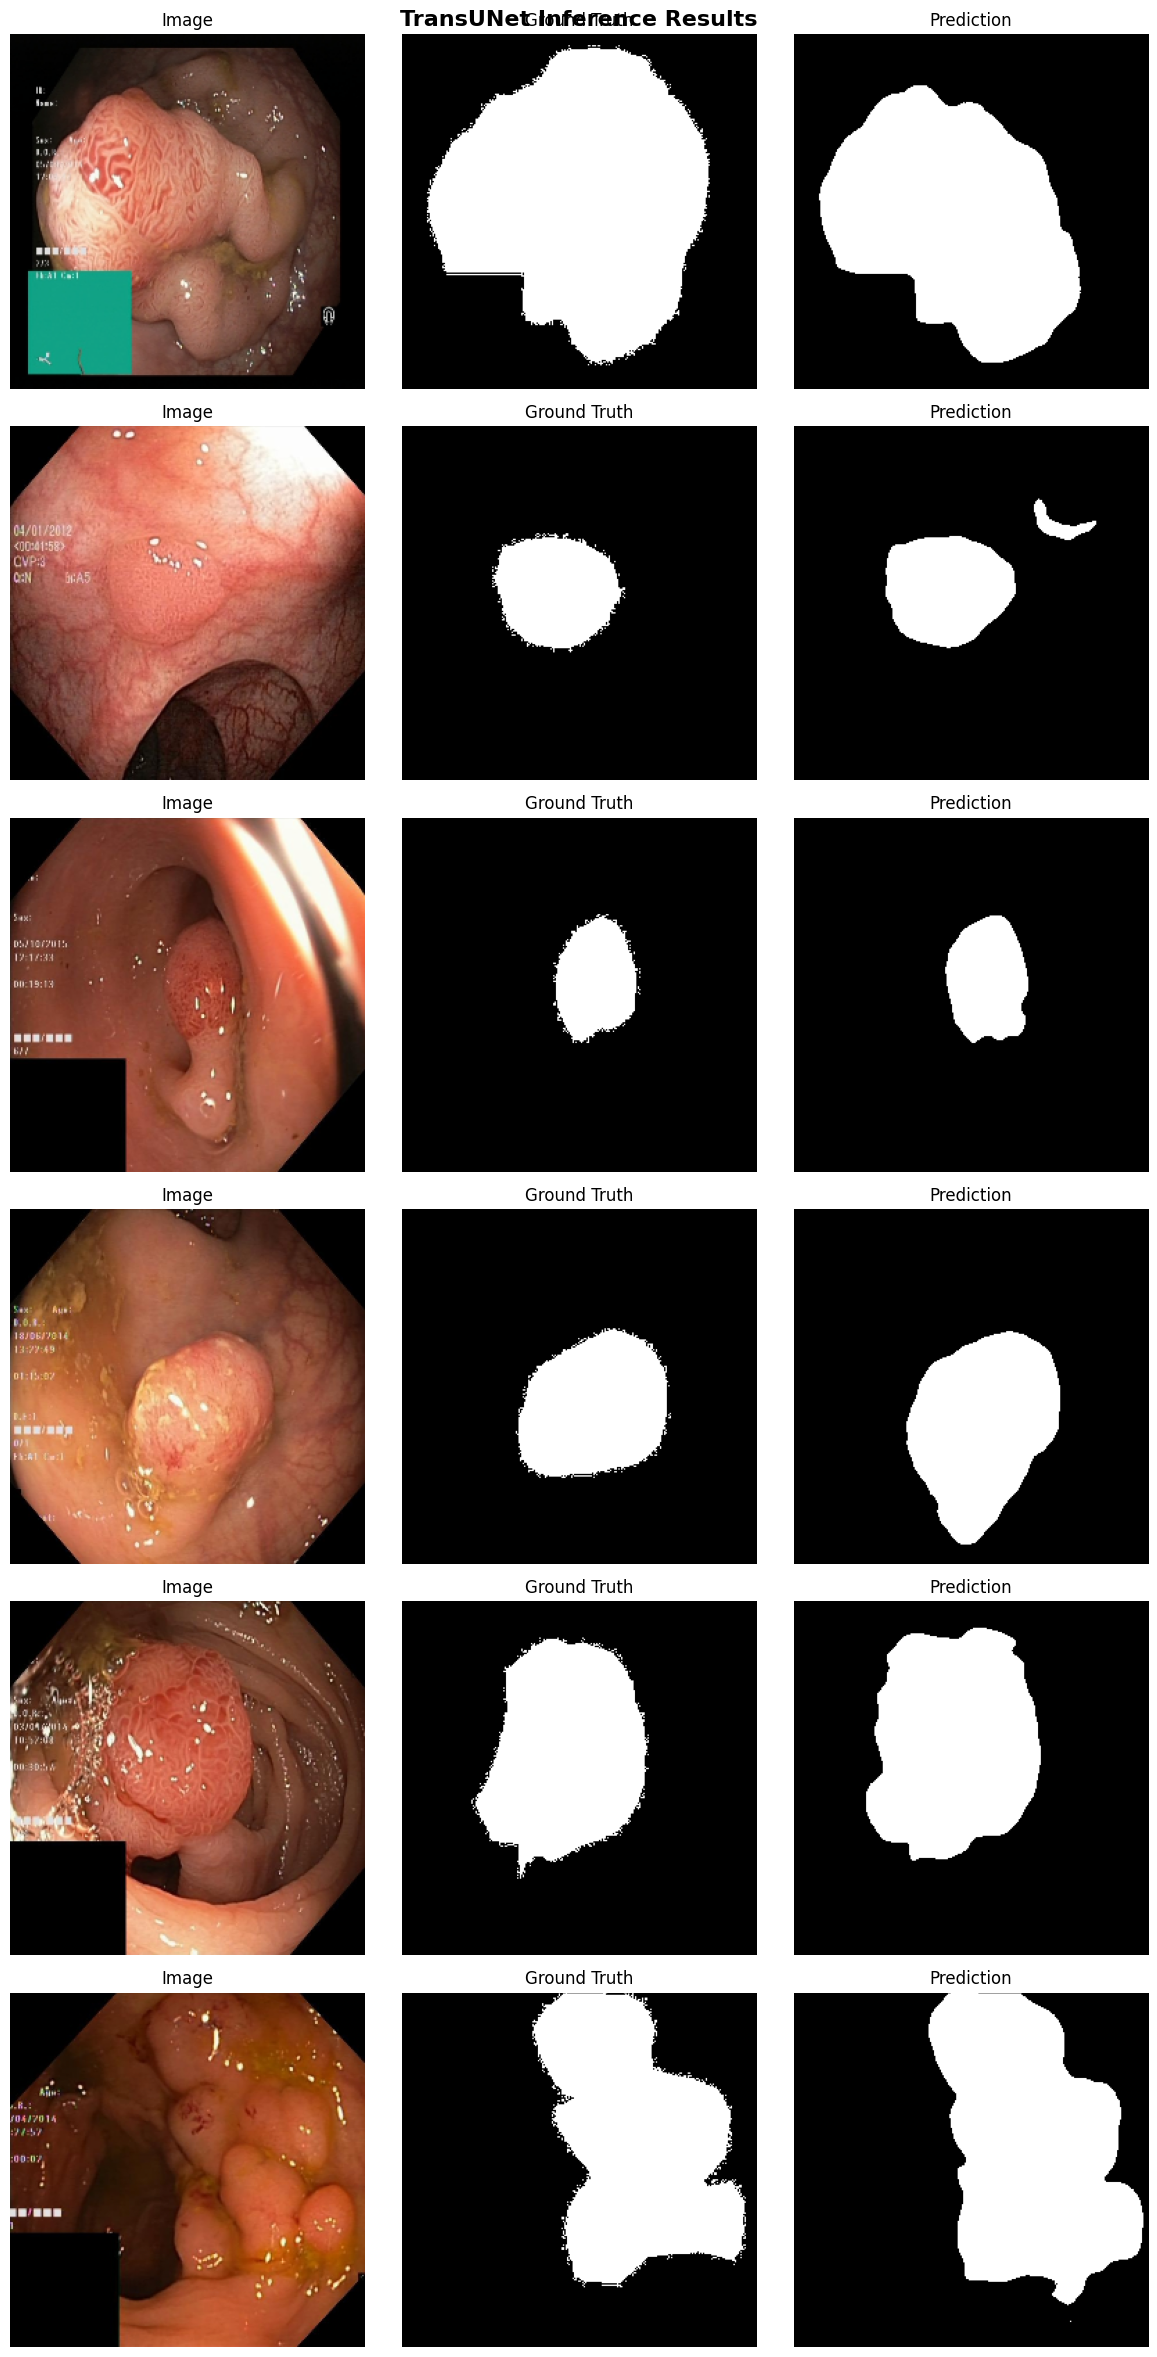

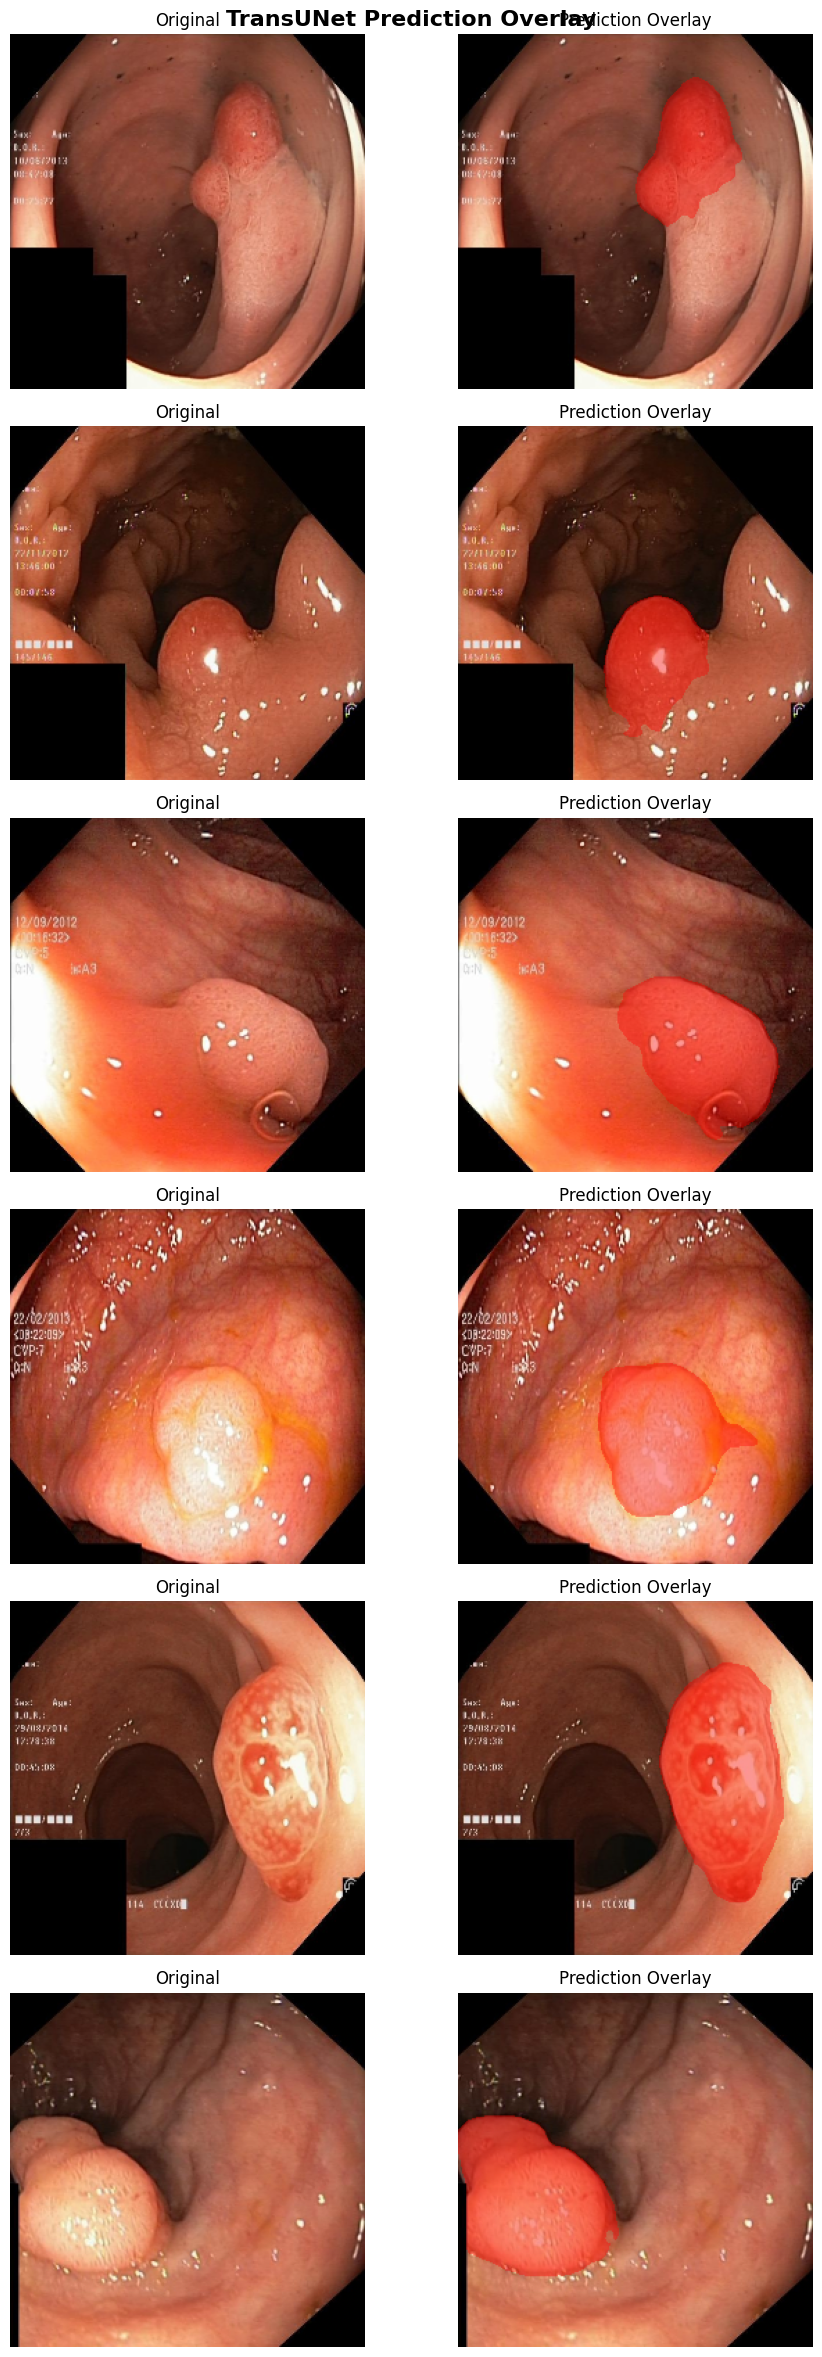

In [18]:
infer_tf = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])


@torch.no_grad()
def predict(model, image_path, device, threshold=0.5):
    img      = np.array(Image.open(image_path).convert("RGB"))
    original = img.copy()
    transformed = infer_tf(image=img)["image"].unsqueeze(0).to(device)
    pred        = torch.sigmoid(model(transformed))   # ← sigmoid since logits
    pred_mask   = (pred.squeeze().cpu().numpy() > threshold).astype(np.uint8)
    return original, pred_mask


def visualize(model, dataset, device, num_samples=6, threshold=0.5):
    model.eval()
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 4))
    fig.suptitle("TransUNet Inference Results", fontsize=16, fontweight="bold")

    for row, idx in enumerate(indices):
        img_tensor, mask_tensor = dataset[idx]
        with torch.no_grad():
            pred      = torch.sigmoid(model(img_tensor.unsqueeze(0).to(device)))
            pred_mask = (pred.squeeze().cpu().numpy() > threshold).astype(np.uint8)

        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        img  = img_tensor.permute(1, 2, 0).numpy()
        img  = (img * std + mean).clip(0, 1)
        gt_mask = mask_tensor.squeeze().numpy()

        axes[row, 0].imshow(img);          axes[row, 0].set_title("Image");        axes[row, 0].axis("off")
        axes[row, 1].imshow(gt_mask, cmap="gray"); axes[row, 1].set_title("Ground Truth"); axes[row, 1].axis("off")
        axes[row, 2].imshow(pred_mask, cmap="gray"); axes[row, 2].set_title("Prediction"); axes[row, 2].axis("off")

    plt.tight_layout()
    plt.savefig("inference_transunet.png", dpi=150, bbox_inches="tight")
    plt.show()


def visualize_overlay(model, dataset, device, num_samples=6, threshold=0.5):
    model.eval()
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, num_samples * 4))
    fig.suptitle("TransUNet Prediction Overlay", fontsize=16, fontweight="bold")

    for row, idx in enumerate(indices):
        img_tensor, mask_tensor = dataset[idx]
        with torch.no_grad():
            pred      = torch.sigmoid(model(img_tensor.unsqueeze(0).to(device)))
            pred_mask = (pred.squeeze().cpu().numpy() > threshold).astype(np.float32)

        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        img  = img_tensor.permute(1, 2, 0).numpy()
        img  = (img * std + mean).clip(0, 1)

        overlay        = img.copy()
        overlay[pred_mask == 1] = [1.0, 0.0, 0.0]
        blended        = (0.6 * img + 0.4 * overlay).clip(0, 1)

        axes[row, 0].imshow(img);     axes[row, 0].set_title("Original");           axes[row, 0].axis("off")
        axes[row, 1].imshow(blended); axes[row, 1].set_title("Prediction Overlay"); axes[row, 1].axis("off")

    plt.tight_layout()
    plt.savefig("overlay_transunet.png", dpi=150, bbox_inches="tight")
    plt.show()


# ── Load best and visualize ───────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
model  = TransUNet(in_channels=3).to(device)
model.load_state_dict(torch.load("best_transunet.pth", map_location=device))
model.eval()

visualize(model, test_ds, device, num_samples=6)
visualize_overlay(model, test_ds, device, num_samples=6)